In [5]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np

## Daten laden und analysieren

In [6]:
df = pd.read_csv(os.path.join('toxic_comments_de.csv'))

In [7]:
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,"""\n\n NPOV wieder\n\nZunächst einmal bin ich B...",0,0,0,0,0,0
1,Ich habe gerade eine auf meiner Benutzerseite ...,0,0,0,0,0,0
2,Dein Name ist ich träume von Pferden was für e...,1,0,1,0,1,0
3,"""\n\n mehr NPOV-Probleme\n\nDieser Artikel ist...",0,0,0,0,0,0
4,"""\n Wir behaupten nie, dass es ein """"Sexspiel""...",0,0,0,0,0,0


In [9]:
df.iloc[148544]['comment_text']

"Das war's, du verdammtes Schwein. Sie verbreiten Ihre Propaganda zu sehr. Sie haben diesen Artikel zu Ihrer eigenen Vorstellung gemacht."

In [10]:
# für jedes Label die Summe an Vorkommnissen (1er) ermitteln
labels = df.columns[1:]
counts = df[labels].sum().sort_values(ascending=False)

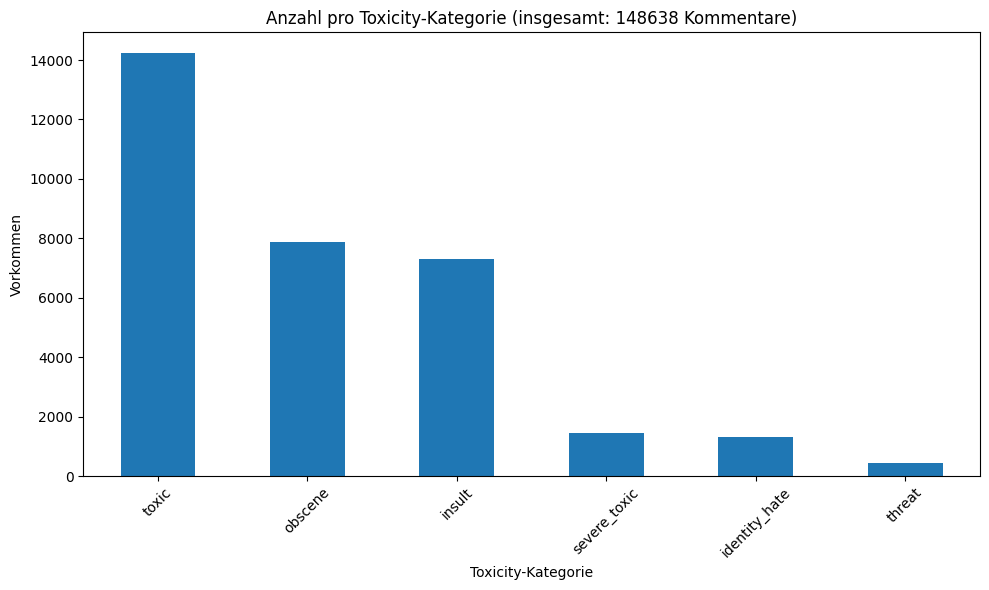

In [11]:
import matplotlib.pyplot as plt

# Vorkommnisse der einzelnen Labels visualisieren
plt.figure(figsize=(10, 6))
counts.plot(kind='bar')
plt.title('Anzahl pro Toxicity-Kategorie (insgesamt: 148638 Kommentare)')
plt.ylabel('Vorkommen')
plt.xlabel('Toxicity-Kategorie')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


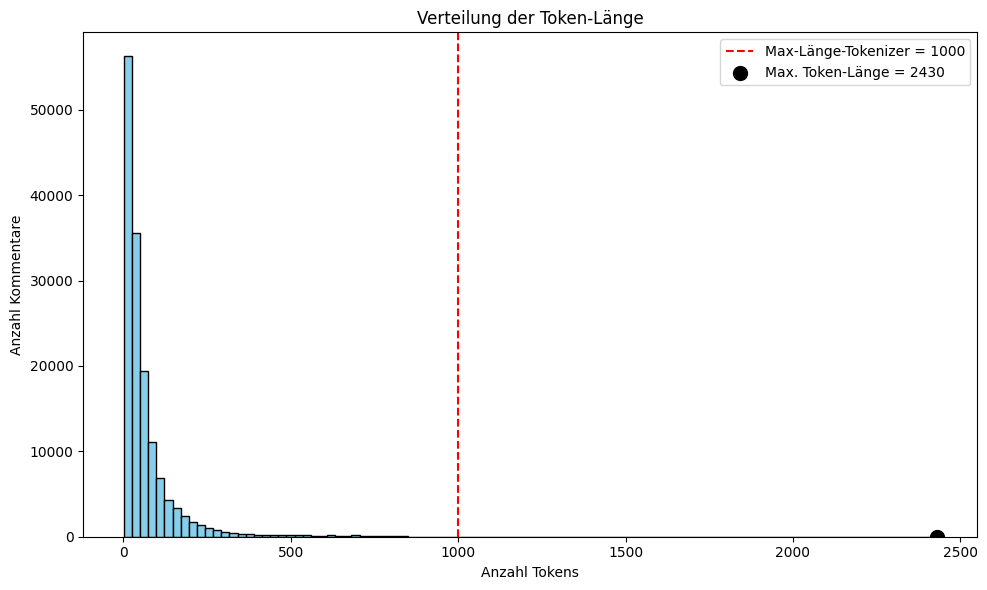

In [12]:
token_lens = [len(text.split()) for text in df['comment_text']]
max_token_len = max(token_lens)
max_length_tokenizer = 1000

plt.figure(figsize=(10, 6))
plt.hist(token_lens, bins=100, color='skyblue', edgecolor='black')

# Roter Strich für maximale output_sequence_length im Vectorizer
plt.axvline(max_length_tokenizer, color='red', linestyle='--', label=f'Max-Länge-Tokenizer = {max_length_tokenizer}')

# Schwarzer Punkt auf der X-Achse für längsten Kommentar
plt.scatter([max_token_len], [0], color='black', zorder=5, label=f'Max. Token-Länge = {max_token_len}', marker='o', s=100)

plt.title('Verteilung der Token-Länge')
plt.xlabel('Anzahl Tokens')
plt.ylabel('Anzahl Kommentare')
plt.legend()
plt.tight_layout()
plt.show()

## Preprosessing
Mapen der Kommentare in Integer Sequenzen

Tensorflow Datapipeline erstellen mit Test, Train und Validation Daten

In [13]:
from tensorflow import keras
from keras.layers import TextVectorization

In [14]:
X = df['comment_text'] # Alle Kommentare (Input-Features)
y = df[df.columns[1:]].values # Array mit "Vektoren" -> ein Vektor pro Kommentar - Zielwerte

In [15]:
MAX_FEATURES = 20_0000 

In [16]:
# Text-Vektorisierung: Umwandlung der Kommentare in Integer-Sequenzen
vectorizer = TextVectorization(
    max_tokens=MAX_FEATURES, 
    output_sequence_length=max_length_tokenizer, 
    output_mode='int'
)
# Punctuation und Whitespaces werden entfernt

In [17]:
vectorizer.adapt(X.values)

In [18]:
vectorizer.get_vocabulary()

['',
 '[UNK]',
 np.str_('die'),
 np.str_('sie'),
 np.str_('ich'),
 np.str_('und'),
 np.str_('der'),
 np.str_('zu'),
 np.str_('ist'),
 np.str_('es'),
 np.str_('nicht'),
 np.str_('dass'),
 np.str_('in'),
 np.str_('von'),
 np.str_('das'),
 np.str_('auf'),
 np.str_('eine'),
 np.str_('ein'),
 np.str_('den'),
 np.str_('für'),
 np.str_('wenn'),
 np.str_('mit'),
 np.str_('habe'),
 np.str_('als'),
 np.str_('haben'),
 np.str_('oder'),
 np.str_('wie'),
 np.str_('artikel'),
 np.str_('sind'),
 np.str_('werden'),
 np.str_('aber'),
 np.str_('um'),
 np.str_('sich'),
 np.str_('du'),
 np.str_('was'),
 np.str_('des'),
 np.str_('er'),
 np.str_('hat'),
 np.str_('einen'),
 np.str_('dem'),
 np.str_('auch'),
 np.str_('an'),
 np.str_('im'),
 np.str_('ihre'),
 np.str_('wird'),
 np.str_('mich'),
 np.str_('wikipedia'),
 np.str_('nur'),
 np.str_('diese'),
 np.str_('über'),
 np.str_('bitte'),
 np.str_('dies'),
 np.str_('wurde'),
 np.str_('mir'),
 np.str_('war'),
 np.str_('können'),
 np.str_('keine'),
 np.str_('aus'

In [19]:
if 'idiot' in vectorizer.get_vocabulary():
    print('Enthalten')
    print(vectorizer('idiot')[:1])

Enthalten
tf.Tensor([382], shape=(1,), dtype=int64)


In [20]:
vectorizer('Hallo und herzlich wilkommen zu meiner Informationssysteme Präsentation')[:8]

<tf.Tensor: shape=(8,), dtype=int64, numpy=array([   114,      5,    926,  66686,      7,    112, 110258,   6090])>

In [21]:
vectorized_text = vectorizer(X.values) # Vektorisierung der Kommentare

In [22]:
vectorized_text

<tf.Tensor: shape=(148645, 1000), dtype=int64, numpy=
array([[ 942,  152, 1366, ...,    0,    0,    0],
       [   4,   22,  279, ...,    0,    0,    0],
       [ 469,  367,    8, ...,    0,    0,    0],
       ...,
       [ 113, 7038,   55, ...,    0,    0,    0],
       [  61,    4,   86, ...,    0,    0,    0],
       [   4,   22,   16, ...,    0,    0,    0]])>

In [23]:
vectorized_array = vectorized_text.numpy().flatten()
vectorized_array_actuall_tokens = [t for t in vectorized_array if t != 0]
vectorized_array_unks = [t for t in vectorized_array if t == 1]

In [24]:
print(f"Anzahl aller Tokens: {len(vectorized_array_actuall_tokens)}")
print(f"Anzahl der [UNK]-Tokens: {len(vectorized_array_unks)}")
unk_ratio = len(vectorized_array_unks) / len(vectorized_array_actuall_tokens)
print(f"Anteil [UNK]: {unk_ratio:.2%}")

Anzahl aller Tokens: 9639488
Anzahl der [UNK]-Tokens: 146024
Anteil [UNK]: 1.51%


In [25]:
dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
dataset = dataset.cache()
dataset = dataset.shuffle(160000)
dataset = dataset.batch(16)
dataset = dataset.prefetch(8)

In [26]:
train = dataset.take(int(len(dataset)*.7))
val = dataset.skip(int(len(dataset)*.7)).take(int(len(dataset)*.2))
test = dataset.skip(int(len(dataset)*.9)).take(int(len(dataset)*.1))

In [27]:
train.as_numpy_iterator().next() # -> 1n Batch - 16 comments mit den 16 passenden lables

(array([[    1,    30,    34, ...,     0,     0,     0],
        [   63,   372,     8, ...,     0,     0,     0],
        [ 2595,    15,   211, ...,     0,     0,     0],
        ...,
        [30111,    37,   294, ...,     0,     0,     0],
        [    2,   275,   121, ...,     0,     0,     0],
        [ 9200, 12510,   171, ...,     0,     0,     0]]),
 array([[0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0]]))

## Erstellen und trainieren des DeepLearning NLP Models

In [28]:
from keras.models import Sequential
from keras.layers import LSTM, Bidirectional, Dense, Embedding

In [30]:
model = Sequential()

# Embedding Layer 
model.add(Embedding(MAX_FEATURES+1, 32)) # -> jedes einzelne Wort hat 32 Features 

# Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(32, activation='tanh')))

# Feature extractor Layers
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))

# Final layer 
model.add(Dense(6, activation='sigmoid')) # 6 "Output" Neuronen

In [31]:
model.compile(loss='binary_crossentropy', optimizer='adam') 

In [32]:
history = model.fit(train, epochs=10, validation_data=val) 

Epoch 1/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1297s 199ms/step - loss: 0.0898 - val_loss: 0.0495
Epoch 2/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1303s 200ms/step - loss: 0.0498 - val_loss: 0.0436
Epoch 3/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1305s 201ms/step - loss: 0.0435 - val_loss: 0.0386
Epoch 4/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1334s 205ms/step - loss: 0.0399 - val_loss: 0.0341
Epoch 5/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1344s 207ms/step - loss: 0.0354 - val_loss: 0.0297
Epoch 6/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1320s 203ms/step - loss: 0.0308 - val_loss: 0.0263
Epoch 7/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1331s 205ms/step - loss: 0.0272 - val_loss: 0.0247
Epoch 8/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1341s 206ms/step - loss: 0.0246 - val_loss: 0.0215
Epoch 9/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1347s 207ms/step - loss: 0.0210 - val_loss: 0.0182
Epoch 10/10
6503/6503 ━━━━━━━━━━━━━━━━━━━━ 1348s 207ms/step - loss: 0.0186 - val_loss: 0.0161


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1000, 32)       │     6,400,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,475,060 (74.29 MB)

 Trainable params: 6,491,686 (24.76 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,983,374 (49.53 MB)

## Auswerten der Model Performance

**loss**: Wie stark weicht das Modell in der aktuellen Epoche auf den Trainingsdaten von den echten Labels ab?

**val_loss**: Wie stark weicht das Modell auf den Validierungsdaten von den echten Labels ab? 

**precision**: Wie viele der als positiv vorhergesagten Labels waren tatsächlich korrekt?

**recall**: Wie viele der tatsächlich positiven Fälle wurden erkannt?

**AUC**: Wie gut kann das Modell zwischen Klassen unterscheiden – unabhängig vom Schwellenwert?

<Figure size 800x500 with 0 Axes>

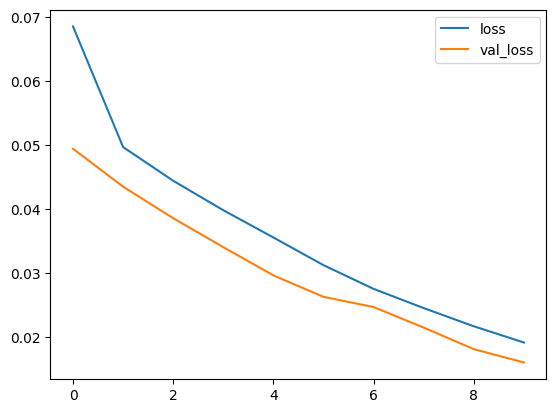

In [36]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8,5))
pd.DataFrame(history.history).plot()
plt.show()

Das Modell zeigt ein zuverlässiges Lernverhalten auf sowohl Trainings- als auch Validierungsdaten.

- Es kann die Trainingsdaten gut vorhersagen (loss sinkt).
- Kann es das Gelernte erfolgreich auf unbekannte Daten übertragen (val_loss sinkt ebenfalls).

=> Das Modell lernt effizient und ohne Anzeichen von Overfitting.

In [37]:
from keras.metrics import AUC, Precision, Recall

In [38]:
pre = Precision()
re = Recall()
auc = AUC()

In [39]:
for batch in test.as_numpy_iterator(): 
    # Batch unpacken
    X_true, y_true = batch
    # Model Prediction durchführen
    yhat = model.predict(X_true)
    
    # -> Konvertieren in ein großes array anstelle von array of arrays
    y_true = y_true.flatten()
    yhat = yhat.flatten()
    
    # Metriken updaten
    pre.update_state(y_true, yhat)
    re.update_state(y_true, yhat)
    auc.update_state(y_true, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━

2025-06-26 21:51:56.513862: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [43]:
overall_precision = pre.result().numpy()
overall_recall = re.result().numpy()
print(f'Precision: {overall_precision}, Recall:{overall_recall}, AUC:{auc.result().numpy()}')

Precision: 0.9286856651306152, Recall:0.9021435379981995, AUC:0.9967814087867737


- **Precision**: Von allen als toxisch predicteten Labels waren ~93 % korrekt
- **Recall**: Von allen tatsächlich toxischen Labels wurden ~90 % erkannt
- **Area under the Curve**: Das Modell unterscheidet fast perfekt toxisch/nicht-toxisch

----

In [41]:
# Für jedes einzelne Label seperat Precision, Recall berechnen
# -> Für jedes Label Metrik initialisieren
num_labels = 6
pre_metrics = [Precision(name=f'precision_{i}') for i in range(num_labels)]
rec_metrics = [Recall(name=f'recall_{i}') for i in range(num_labels)]

for batch in test.as_numpy_iterator():
    # Batch unpacken
    X_true, y_true = batch
    # Model Prediction durchführen
    yhat = model.predict(X_true)

    # Für jedes Label einzeln updaten
    for i in range(num_labels):
        pre_metrics[i].update_state(y_true[:, i], yhat[:, i])
        rec_metrics[i].update_state(y_true[:, i], yhat[:, i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

2025-06-26 21:55:58.513968: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


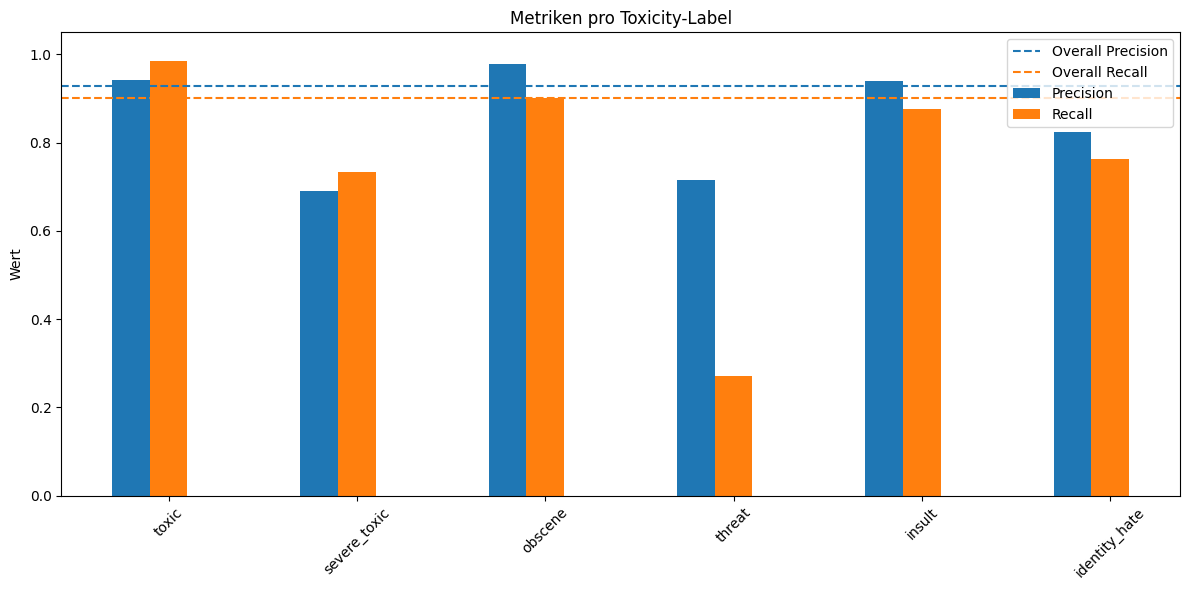

In [ ]:
# Liste für jede Metrik mit dem Gesamtergebnis pro Label
precision_vals = [m.result().numpy() for m in pre_metrics]
recall_vals = [m.result().numpy() for m in rec_metrics]

# Balkendiagramm zeichnen
x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(12, 6))

# Pre und RE pro Label
plt.bar(x, precision_vals, width, label='Precision', color='tab:blue')
plt.bar(x + width, recall_vals, width, label='Recall', color='tab:orange')

# Gesamt PRe und Re
plt.xticks(x + width, labels, rotation=45)
plt.axhline(overall_precision, linestyle='--', color='tab:blue', label='Overall Precision')
plt.axhline(overall_recall, linestyle='--', color='tab:orange', label='Overall Recall')

plt.ylim(0, 1.05)
plt.ylabel('Wert')
plt.title('Metriken pro Toxicity-Label')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
input_text = vectorizer('Er ist ein absoluter Idiot')

In [30]:
model.predict(np.expand_dims(input_text,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


array([[0.965818  , 0.00123662, 0.01878498, 0.02520397, 0.47938716,
        0.02771123]], dtype=float32)

## Model speichern

In [4]:
from pathlib import Path

notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent
models_dir = parent_dir / 'models'

In [ ]:
model.save(models_dir / 'toxicity.keras')

In [ ]:
tf.keras.models.save_model(vectorizer, models_dir / 'vectorizer.keras')